# Getting the Most out of GPT-5.4 for Vision and Document Understanding

GPT-5.4 is a major step forward for real-world multimodal workloads.

Documents that previously strained vision systems or required stitching together OCR, layout detection, and custom parsers, including dense scans, handwritten forms, engineering diagrams, and chart-heavy reports, can now often be interpreted and reasoned over in a single model pass with GPT-5.4.

However, model configuration is key for unlocking SOTA results. Small choices around image detail, verbosity, reasoning effort, and tool usage can significantly affect performance. 

This notebook focuses on the highest-leverage adjustments for document workloads: image detail, verbosity, reasoning effort, and tool use. The goal is to show when each one matters, how it changes the output, and how to choose a setup that is both robust and practical.

All examples in this notebook use the **Responses API** via `client.responses.create(...)`. The “settings” we talk about are request parameters you pass into that call.

### Input shape

- **`input`**: a list of message-like objects (commonly one `{ "role": "user", "content": [...] }`)
- **`content`**: a list of typed blocks, typically:
  - `{ "type": "input_text", "text": "..." }`
  - `{ "type": "input_image", "image_url": "...", "detail": "auto" | "original" }`

### Parameters used throughout this notebook

- **Image detail** (`input_image.detail`): controls the image resolution used for vision. Use `"auto"` for most pages; use `"original"` when text is tiny, handwritten, or the scan is low-quality.
- **Verbosity** (`text={"verbosity": ...}`): influences how compressed vs literal the text output is. Higher verbosity is helpful for faithful transcription.
- **Reasoning effort** (`reasoning={"effort": ...}`): allocates more compute to multi-step visual reasoning (charts, tables, diagrams) once the image is already readable.
- **Tool use** (`tools=[...]` + `instructions=...`): optionally lets the model use tools like **Code Interpreter** to zoom/crop/inspect before answering; omit tools when a single-pass answer is enough.

A minimal request looks like:

```python
response = client.responses.create(
    model="gpt-5.4",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": "Extract the total amount due."},
                {
                    "type": "input_image",
                    "image_url": "data:image/png;base64,...",
                    "detail": "auto",
                },
            ],
        }
    ],
)
```

### Output shape

- The model returns a **response object** with one or more output items.
- In this notebook, we mostly use `response.output_text` as a convenient way to get the final text.
- For **structured outputs**, you still receive text — you just ask the model to format it as JSON using `text={"format": ...}` and then `json.loads(response.output_text)`. 


## A quick decision guide
Use this as a starting point. A good rule of thumb is to start simple, then adjust the setting that matches the failure mode. 

| If your task looks like this | Start with this setup | Why |
|---|---|---|
| Ordinary document QA or extraction | `detail="auto"` | Lowest-friction default for readable pages |
| Dense scans, screenshots, handwriting, or tiny labels | `detail="original"` | Preserves small visual signals that often get lost |
| Literal transcription or markdown conversion | `text={"verbosity": "high"}` | Encourages the model to keep more layout and fewer paraphrases |
| Region localization | Ask for `[x_min, y_min, x_max, y_max]` in a fixed `0..999` grid | Easy to crop, draw, debug, and feed into downstream systems |
| Chart, table, form, or drawing QA across multiple regions | increase reasoning effort to 'high' or 'xhigh' | Improves multi-step visual reasoning |
| Multi-pass visual inspection | Add Code Interpreter | Best when a human would zoom, crop, rotate, or inspect several subregions before answering |

## Setup

Before running this notebook, make sure you have `OPENAI_API_KEY` set in your environment. If you don’t have an API key yet, you can create one at [platform.openai.com](https://platform.openai.com/api-keys).

```bash
export OPENAI_API_KEY="your_api_key_here"
```

If needed, install the notebook dependencies:

```bash
pip install --upgrade openai pillow
```

In [7]:
import base64
import json
import mimetypes
import tempfile
from pathlib import Path

from IPython.display import Markdown, display
from PIL import Image, ImageDraw
from openai import OpenAI

client = OpenAI()

In [ ]:
### Helper function

def image_to_data_url(image_path: str | Path) -> str:
    path = Path(image_path)
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    mime_type = mimetypes.guess_type(path.name)[0] or "image/png"
    encoded = base64.b64encode(path.read_bytes()).decode("ascii")
    return f"data:{mime_type};base64,{encoded}"

## 1. Increase image detail for dense pages and handwriting

The `detail` parameter controls the resolution the model uses when processing an image. Most applications should start with `detail="auto"` which lets the model choose an appropriate resolution. However, when pages contain handwriting, small labels, dense tables, low contrast scans, or screenshots with fine text, switching to `detail="original"` can significantly improve results. If the model is mostly correct but consistently misses small fields or annotations, increasing image detail is usually the first adjustment to try.

This example intentionally includes small email and phone fields, not just the larger handwritten names. Those are the kinds of details that tend to degrade first when the image is downsampled.

<img src="../../images/3C_insurance_form.png" alt="Handwritten insurance form" style="max-width: 100%; width: 720px;" />


In [ ]:
handwriting_prompt = """
Read the handwritten earthquake insurance application and return JSON with these keys:
- applicant_name
- applicant_email
- applicant_home_phone
- applicant_cell_phone
- co_applicant_name
- co_applicant_email
- co_applicant_home_phone
- co_applicant_work_phone
- effective_date
- expiration_date
- dwelling_coverage_limit_usd
- square_footage
- year_of_construction
"""

handwritten_form_path = "../../images/3C_insurance_form.png"
handwriting_response = client.responses.create(
    model="gpt-5.4",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": handwriting_prompt},
                {
                    "type": "input_image",
                    "image_url": image_to_data_url(handwritten_form_path),
                    "detail": "original",
                },
            ],
        }
    ],
    text={"format": {"type": "json_object"}
    },
)

handwriting_result = json.loads(handwriting_response.output_text)
display(Markdown(f"### Extracted insurance form\n\n```json\n{json.dumps(handwriting_result, indent=2, ensure_ascii=False)}\n```"))

### Extracted insurance form

```json
{
  "applicant_name": "Smith, James L",
  "applicant_email": "jsmith1@gmail.com",
  "applicant_home_phone": "510 331 5555",
  "applicant_cell_phone": "510 212 5555",
  "co_applicant_name": "Roberts, Jesse T",
  "co_applicant_email": "jrobertsjr@gmail.com",
  "co_applicant_home_phone": "510 331 5555",
  "co_applicant_work_phone": "415 626 5555",
  "effective_date": "5/31/25",
  "expiration_date": "5/31/27",
  "dwelling_coverage_limit_usd": 900000,
  "square_footage": 1200,
  "year_of_construction": 2005
}
```

## 2. Increase verbosity for faithful transcription

When asked to transcribe documents, multimodal models tend to compress layout. They preserve meaning but may simplify whitespace, line breaks, and table-like layout. This behavior is often desirable for question answering, but not for OCR-style tasks.

Increase verbosity - `text={"verbosity": "high"}` encourages the model toward a more literal rendering and precise transcription. Use it for OCR-style workloads and targeted extractions where completeness and formatting fidelity matter.

The example below  `Ticket To The Arts` panel, asking for a full transcription of all four listings while keeping the image detail fixed.

<img src="images/newspaper.png" alt="Newspaper clipping" style="max-width: 100%; width: 720px;" />


In [ ]:
section_prompt = "Transcribe everything in the Ticket To The Arts section. Do not summarize or paraphrase. Do not add any additional text."

newspaper_path = "../../examples/multimodal/images/newspaper.png"
section_response = client.responses.create(
    model="gpt-5.4",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": section_prompt},
                {
                    "type": "input_image",
                    "image_url": image_to_data_url(newspaper_path),
                    "detail": "original",
                },
            ],
        }
    ],
    text={"verbosity": "high"},
)

display(Markdown(f"### Transcription preview\n\n```text\n{section_response.output_text}\n```"))

### Transcription preview

```text
Ticket To
The Arts

THEATER

MUSIC

CRUMBS FROM THE TABLE OF
JOY

NOW-FEBRUARY 2

BY LYNN NOTTAGE

DIRECTED BY TASIA A. JONES

Set in 1950’s Brooklyn, two sisters mourn
the loss of their mother with Hollywood films,
daydreams, and lots of cookies. When a shocking
decision is made by their father, the family must
find new meaning in what makes a home. Tickets
at lyricstage.com or by calling the box office at
617-585-5678

RUSSIAN WINTER

Sun. 1/12 at 3PM, Sanders Theatre

Prokofiev: Quintet in G minor, Op. 39
Arensky: Piano Trio No. 1 in D minor, Op. 32
Glazunov: String Quintet in A major, Op. 39

$30-$68; Sr: $4 off; Student: $9
617.349.0086 / bostonchambermusic.org

DANCE

MUSIC

BACK IN BOSTON FOR THE 1ST
TIME IN 6 YEARS!

Legendary dance company Mark Morris Dance
Group performs “The Look of Love” — a must-
see homage to the chart-topping hits of Burt
Bacharach, including “I Say a Little Prayer,”
“What the World Needs Now” & more. A powerful
fusion of dance and music feat. a live band and
vocals sung by Broadway star Marcy Harriell,
“this is choreography that, in the words of the
song, says ‘more than just words could ever
say.’ ” —The New York Times

Jan 23–26, Emerson Cutler Majestic Theatre
For tix & info: globalartslive.org 617.876.4275

SPM CELEBRATES THEA
MUSGRAVE

Musgraves Turbulent Landscapes, Elgar Enigma
Variations, Wm. Walton Portsmouth Point. Sat
Jan 25 7:30pm Hudson High School, Sun Jan 26
3:00pm St. John’s Founders Hall, Shrewsbury.
Tix: https://www.symphonypromusica.org
```

## 3. Raise reasoning effort when the image is readable but the answer is compositional

Once the image is readable, the next bottleneck is often reasoning instead of perception. This shows up in documents where the answer depends on combining information across multiple parts of the image rather than reading a single field. Charts, tables, technical diagrams, and dense visual layouts often fall into this category.

In those cases, increasing reasoning effort `reasoning={"effort": "high"}` can help more than increasing image detail. The model already sees the content. What it needs is more capacity to connect labels, compare regions, follow structure, and compute the final answer correctly.

Below are examples of different types of tasks or images where higher reasoning is helpful.

### Example: floorplan reasoning

The floorplan below is a good example of a task that goes beyond transcription. To answer correctly, the model has to read room labels, interpret spatial relationships, and use visible dimensions to compute values.

<img src="images/apartment_floorplan.png" alt="Apartment floorplan" style="max-width: 100%; width: 720px;" />


In [ ]:
floorplan_prompt = """
Inspect this apartment floorplan and return JSON with these keys:
- total_named_rooms_excluding_hallways_and_closets
- largest_room
- room_immediately_east_of_kitchen
- room_immediately_south_of_study
- bedroom_1_total_area_ft2
- bedroom_2_total_area_ft2

Rules:
- Use the room labels and dimension annotations that are visible on the drawing.
- Return integers for numeric fields.
- Return JSON only.
"""

floorplan_path = "../../examples/multimodal/images/apartment_floorplan.png"
floorplan_response = client.responses.create(
    model="gpt-5.4",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": floorplan_prompt},
                {
                    "type": "input_image",
                    "image_url": image_to_data_url(floorplan_path),
                    "detail": "original",
                },
            ],
        }
    ],
    reasoning={"effort": "high"},
    text={"format": {"type": "json_object"}},
)

floorplan_result = json.loads(floorplan_response.output_text)
display(Markdown(f"### Floorplan reasoning result\n\n```json\n{json.dumps(floorplan_result, indent=2, ensure_ascii=False)}\n```"))

### Floorplan reasoning result

```json
{
  "total_named_rooms_excluding_hallways_and_closets": 7,
  "largest_room": "Living Room",
  "room_immediately_east_of_kitchen": "Dining",
  "room_immediately_south_of_study": "Bedroom 2",
  "bedroom_1_total_area_ft2": 168,
  "bedroom_2_total_area_ft2": 96
}
```

### Example: chart understanding

The same pattern shows up in chart understanding. If the task is simply to read a title or identify one plotted value, default settings may be enough. But if the answer depends on comparing multiple series, tracking changes across adjacent intervals, or estimating trends over time, reasoning becomes the limiting factor.

<img src="../../images/NotRealCorp_chart.png" alt="Line chart" style="max-width: 100%; width: 720px;" />


In [44]:
chart_prompt = """
Inspect this line chart and return a JSON with these keys:
- largest_qoq_increase: {"channel": ..., "from_quarter": ..., "to_quarter": ..., "approx_delta_millions": ...}
- largest_qoq_drop: {"channel": ..., "from_quarter": ..., "to_quarter": ..., "approx_delta_millions": ...}
- fastest_growing_channel_overall

Rules:
- Use approximate values only when exact values are not printed.
- Base the answer on the visible lines and quarter labels.
- Return JSON only.
"""

chart_path = "../../images/NotRealCorp_chart.png"
chart_response = client.responses.create(
    model="gpt-5.4",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": chart_prompt},
                {
                    "type": "input_image",
                    "image_url": image_to_data_url(chart_path),
                    "detail": "original",
                },
            ],
        }
    ],
    reasoning={"effort": "high"},
    text={"format": {"type": "json_object",}},
)

chart_result = json.loads(chart_response.output_text)
display(Markdown(f"### Chart reasoning result\n\n```json\n{json.dumps(chart_result, indent=2, ensure_ascii=False)}\n```"))

### Chart reasoning result

```json
{
  "largest_qoq_increase": {
    "channel": "Online Sales",
    "from_quarter": "2021 Q4",
    "to_quarter": "2022 Q1",
    "approx_delta_millions": 0.15
  },
  "largest_qoq_drop": {
    "channel": "Retail Partners",
    "from_quarter": "2023 Q4",
    "to_quarter": "2024 Q1",
    "approx_delta_millions": -0.06
  },
  "fastest_growing_channel_overall": "Online Sales"
}
```

### Example: long-range visual reasoning on a dense bracket

Dense tournament brackets are a strong candidate for reasoning because the model has to follow paths across a crowded layout, keep left and right regions distinct, and identify the final outcomes without losing track of structure.

<img src="images/bracket.png" alt="Tournament bracket" style="max-width: 100%; width: 1000px;" />


In [ ]:
bracket_prompt = """
Inspect this tournament bracket image and return JSON with these keys:
- left_bracket_title
- right_bracket_title
- mens_champion_team
- womens_champion_team
- mens_runner_up_team
- womens_runner_up_team

Rules:
- Use the visible central championship score boxes.
- Team labels may include seeds; if you include a seed, keep it attached to the same string.
- Return JSON only.
"""

bracket_path = "../../examples/multimodal/images/bracket.png"
bracket_response = client.responses.create(
    model="gpt-5.4",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": bracket_prompt},
                {
                    "type": "input_image",
                    "image_url": image_to_data_url(bracket_path),
                    "detail": "original",
                },
            ],
        }
    ],
    reasoning={"effort": "high"},
    text={"format": {"type": "json_object"}},
)

bracket_result = json.loads(bracket_response.output_text)
display(Markdown(f"### Bracket reasoning result\n\n```json\n{json.dumps(bracket_result, indent=2, ensure_ascii=False)}\n```"))

### Bracket reasoning result

```json
{
  "left_bracket_title": "Women’s Bracket",
  "right_bracket_title": "Men’s Bracket",
  "mens_champion_team": "Connecticut 4",
  "womens_champion_team": "L.S.U. 3",
  "mens_runner_up_team": "5 S.D. State",
  "womens_runner_up_team": "2 Iowa"
}
```

## 4. Use Code Interpreter for multi-pass inspection and bounding-box localization

Some document tasks are easier to solve the way a person would: inspect the full page, zoom or crop a region, check another area, and then combine evidence into a final answer.

Code Interpreter is particularly useful for vision tasks when:
- the page is dense and evidence is spread across multiple regions
- the model needs to zoom, crop, rotate, or run intermediate checks
- qualitative accuracy matters more than minimum latency

For localization tasks (including bounding boxes), provide access to code interpreter as well as a strict coordinate contract like `[x_min, y_min, x_max, y_max]` and a fixed coordinate space such as `0..999` with the origin in the top-left corner.

In practice, this combination (code interpreter tool use + explicit box format) is often more reliable and repeatable than a single-pass vision call.

<img src="images/police_form.png" alt="Police report form" style="max-width: 100%; width: 720px;" />


### Detected plate regions

```json
[
  {
    "label": "vehicle_1_license_plate",
    "bbox": [
      136,
      308,
      178,
      315
    ]
  },
  {
    "label": "vehicle_2_license_plate",
    "bbox": [
      136,
      662,
      188,
      669
    ]
  }
]
```

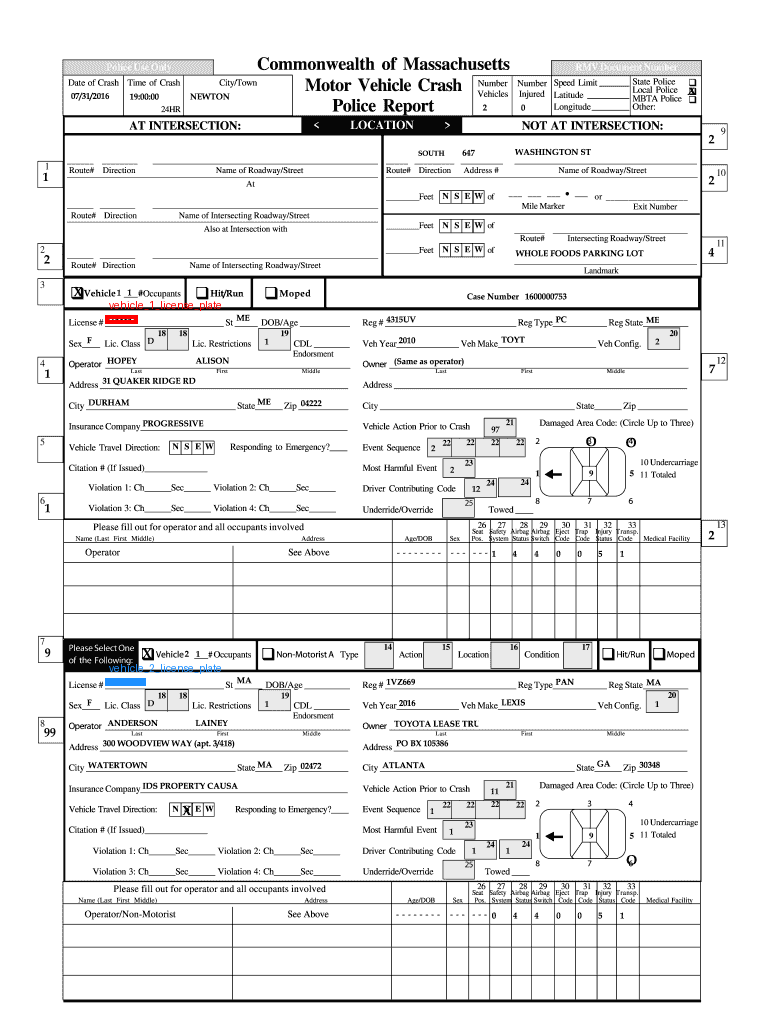

In [41]:
bbox_prompt = """
Find the license plate number for Vehicle 1 and Vehicle 2 in this police report form.
It is written after License # and is a 7-digit number.
Do not guess or infer the license plate number.

Return JSON with this schema:
{
  "b": [
    {"label": "vehicle_1_license_plate", "bbox": [x_min, y_min, x_max, y_max]},
    {"label": "vehicle_2_license_plate", "bbox": [x_min, y_min, x_max, y_max]}
  ]
}

Use discrete normalized coordinates between 0 and 999.
Return JSON only.
"""

police_form_path = "../../examples/multimodal/images/police_form.png"
with Path(police_form_path).open("rb") as asset_file:
    uploaded_file = client.files.create(file=asset_file, purpose="user_data")

bbox_schema = {
    "type": "object",
    "properties": {
        "b": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "label": {
                        "type": "string",
                        "enum": ["vehicle_1_license_plate", "vehicle_2_license_plate"],
                    },
                    "bbox": {
                        "type": "array",
                        "items": {"type": "integer", "minimum": 0, "maximum": 999},
                        "minItems": 4,
                        "maxItems": 4,
                    },
                },
                "required": ["label", "bbox"],
                "additionalProperties": False,
            },
            "minItems": 2,
            "maxItems": 2,
        }
    },
    "required": ["b"],
    "additionalProperties": False,
}

bbox_response = client.responses.create(
    model="gpt-5.4",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": bbox_prompt},
                {
                    "type": "input_image",
                    "image_url": image_to_data_url(police_form_path),
                    "detail": "original",
                },
            ],
        }
    ],
    reasoning={"effort": "high"},
    text={
        "format": {
            "type": "json_schema",
            "name": "plate_bboxes",
            "schema": bbox_schema,
            "strict": True,
        }
    },
    instructions=(
        "You are an expert document analyst. Use Code Interpreter before answering. "
        "Inspect the uploaded file, crop or zoom if needed, then answer in JSON."
    ),
    tools=[
        {
            "type": "code_interpreter",
            "container": {
                "type": "auto",
                "memory_limit": "4g",
                "file_ids": [uploaded_file.id],
            },
        }
    ],
)

bbox_results = json.loads(bbox_response.output_text)["b"]
display(Markdown(f"### Detected plate regions\n\n```json\n{json.dumps(bbox_results, indent=2, ensure_ascii=False)}\n```"))

annotated = Image.open(police_form_path).convert("RGB")
draw = ImageDraw.Draw(annotated)
width, height = annotated.size
palette = ["red", "dodgerblue", "limegreen", "orange", "magenta", "cyan"]

for index, item in enumerate(bbox_results):
    color = palette[index % len(palette)]
    x_min, y_min, x_max, y_max = item["bbox"]
    pixel_bbox = [
        round(x_min * (width - 1) / 999),
        round(y_min * (height - 1) / 999),
        round(x_max * (width - 1) / 999),
        round(y_max * (height - 1) / 999),
    ]
    draw.rectangle(pixel_bbox, outline=color, width=4)
    draw.text((pixel_bbox[0] + 4, max(0, pixel_bbox[1] - 16)), item["label"], fill=color)

display(annotated)


## 5. If you cannot use Code Interpreter, build a narrow crop-and-rerun pipeline

In restricted environments, you may not want to grant the model a general Python sandbox. A practical alternative is a two-stage workflow:

1. localize the field or region you care about
2. crop that region locally
3. rerun a smaller, more focused prompt on the crop

This often recovers much of the value of multi-pass inspection while keeping the control surface small.


In [47]:
target_region = next(
    item for item in bbox_results if item["label"] == "vehicle_2_license_plate"
)

source_image = Image.open(police_form_path).convert("RGB")
width, height = source_image.size
x_min, y_min, x_max, y_max = target_region["bbox"]
pixel_bbox = [
    round(x_min * (width - 1) / 999),
    round(y_min * (height - 1) / 999),
    round(x_max * (width - 1) / 999),
    round(y_max * (height - 1) / 999),
]
padding = 0.18
pad_x = round((pixel_bbox[2] - pixel_bbox[0]) * padding)
pad_y = round((pixel_bbox[3] - pixel_bbox[1]) * padding)
crop = source_image.crop(
    (
        max(0, pixel_bbox[0] - pad_x),
        max(0, pixel_bbox[1] - pad_y),
        min(width, pixel_bbox[2] + pad_x),
        min(height, pixel_bbox[3] + pad_y),
    )
)

tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
crop_path = Path(tmp.name)
tmp.close()
crop.save(crop_path)

display(crop)

crop_prompt = """
Read the license number value in this cropped police-form region.
It is next to the word License #.

Return JSON with one key:
- license_number

Return JSON only.
"""

crop_schema = {
    "type": "object",
    "properties": {
        "license_number": {"type": "string"},
    },
    "required": ["license_number"],
    "additionalProperties": False,
}

crop_response = client.responses.create(
    model="gpt-5.4",
    input=[
        {
            "role": "user",
            "content": [
                {"type": "input_text", "text": crop_prompt},
                {
                    "type": "input_image",
                    "image_url": image_to_data_url(crop_path),
                    "detail": "original",
                },
            ],
        }
    ],
    text={
        "format": {
            "type": "json_schema",
            "name": "license_number_extraction",
            "schema": crop_schema,
            "strict": True,
        }
    },
)

crop_result = json.loads(crop_response.output_text)
display(Markdown(f"### Crop-and-rerun result\n\n```json\n{json.dumps(crop_result, indent=2, ensure_ascii=False)}\n```"))


### Crop-and-rerun result

```json
{
  "license_number": "S76389777"
}
```

## Conclusion

To summarize, start simple: use native vision with detail="auto" and no tools when the task is simple and the page is clear.

Raise image detail (detail="original") when text is tiny, handwritten, low-contrast, or scan quality is poor.

Raise verbosity when you need faithful transcription rather than compressed summaries.

Raise reasoning effort when the image is readable but the answer requires combining multiple regions.

Use Code Interpreter for multi-pass inspection (zoom/crop/rotate), especially on dense pages.

For bounding boxes, require a strict contract: [x_min, y_min, x_max, y_max] in a fixed 0..999 coordinate space (top-left origin), and enforce structured JSON output.

If Code Interpreter is unavailable, use crop-and-rerun: localize, crop locally, then run a focused extraction prompt.

In restricted environments, expose lightweight visual tools (crop/zoom/rotate/OCR-region fallback) for tighter control.